<a href="https://colab.research.google.com/github/MaulikVaghela006/VOIS_AICTE_Oct2025_Vaghela_Maulik/blob/main/Air_bnb_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
#import pandas as pd

file_path = "/content/Airbnb_Data.csv"
df = pd.read_csv(file_path)

print(df.head())


        id                                              NAME      host id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3  1002755                                               NaN  85098326012   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   

  host_identity_verified host name neighbourhood group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2                    NaN     Elise           Manhattan        Harlem   
3            unconfirmed     Garry            Brooklyn  Clinton Hill   
4               verified    Lyndon           Manhattan   East Harlem   

        lat      long        country  ... service fee minimum nights  \
0  40.64749 -73.97237  United St

In [5]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')

In [6]:
print(df.isnull().sum())

id                                    0
NAME                                 76
host id                               0
host_identity_verified               95
host name                            39
neighbourhood group                  27
neighbourhood                        16
lat                                   9
long                                  9
country                              51
country code                         80
instant_bookable                     80
cancellation_policy                  51
room type                             1
Construction year                   147
price                                65
service fee                          63
minimum nights                      161
number of reviews                    21
last review                        3200
reviews per month                  3186
review rate number                  104
calculated host listings count       61
availability 365                    159
house_rules                        6103


In [7]:
# Convert 'last review' to datetime and handle errors
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')

# Fill missing values
df.fillna({'reviews per month': 0, 'last review': df['last review'].min()}, inplace=True)

# Drop records with missing 'name' or 'host name'
df.dropna(subset=['NAME', 'host name'], inplace=True)

In [8]:
# Remove dollar signs and convert to float
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df['service fee'] = df['service fee'].replace('[\$,]', '', regex=True).astype(float)

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-138066982.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
/tmp/ipython-input-138066982.py:3: SyntaxWarning: invalid escape sequence '\$'
  df['service fee'] = df['service fee'].replace('[\$,]', '', regex=True).astype(float)


In [10]:
df.drop_duplicates(inplace=True)

In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 18333 entries, 0 to 18441
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              18333 non-null  int64         
 1   NAME                            18333 non-null  object        
 2   host id                         18333 non-null  int64         
 3   host_identity_verified          18248 non-null  object        
 4   host name                       18333 non-null  object        
 5   neighbourhood group             18309 non-null  object        
 6   neighbourhood                   18317 non-null  object        
 7   lat                             18324 non-null  float64       
 8   long                            18324 non-null  float64       
 9   country                         18288 non-null  object        
 10  country code                    18262 non-null  object        
 11  instant

In [12]:
print(df.describe())

                 id       host id           lat          long  \
count  1.833300e+04  1.833300e+04  18324.000000  18324.000000   
mean   6.109809e+06  4.905715e+10     40.729967    -73.957910   
min    1.001254e+06  1.303496e+08     40.499790    -74.242850   
25%    3.572293e+06  2.431687e+10     40.690053    -73.983450   
50%    6.110663e+06  4.873875e+10     40.723940    -73.958620   
75%    8.645720e+06  7.379746e+10     40.764350    -73.942370   
max    1.118630e+07  9.873673e+10     40.908040    -73.712990   
std    2.930356e+06  2.850115e+10      0.052493      0.037305   

       Construction year         price   service fee  minimum nights  \
count       18199.000000  18268.000000  18270.000000    18178.000000   
mean         2012.478103    618.155025    123.564313        7.956156   
min          2003.000000     50.000000     10.000000      -12.000000   
25%          2007.000000    327.000000     65.000000        1.000000   
50%          2012.000000    613.000000    123.000000  

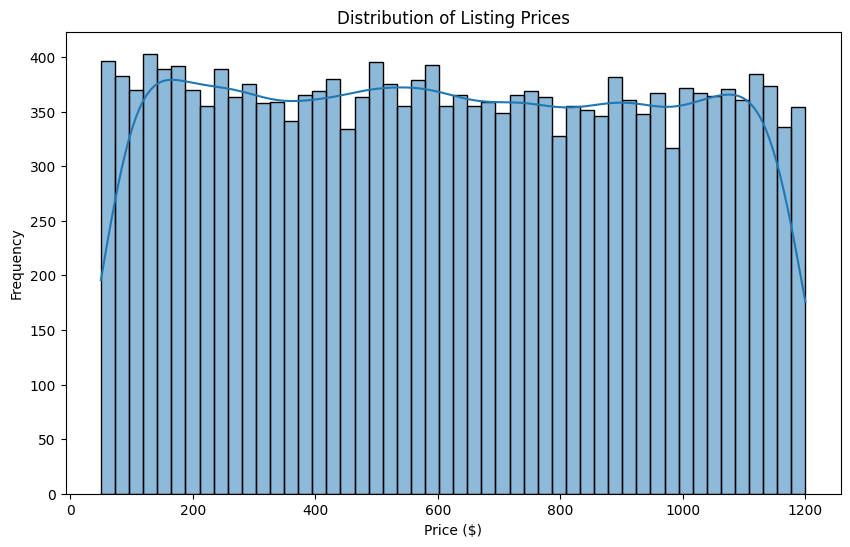

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Listing Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

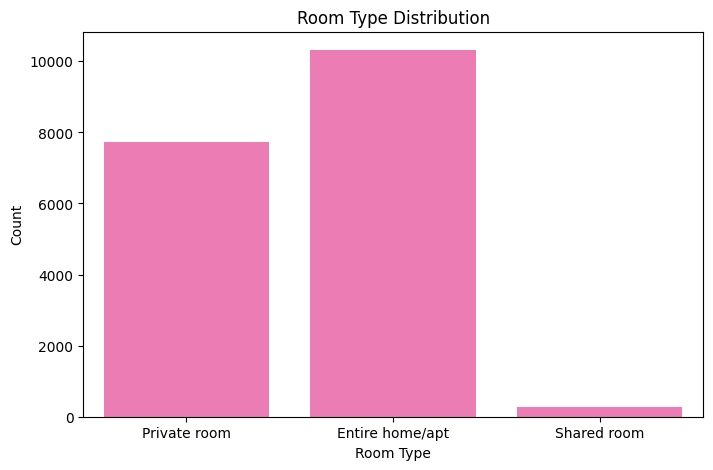

In [15]:
#room type analysis
plt.figure(figsize=(8, 5))
sns.countplot(x='room type', data=df , color='hotpink')
plt.title('Room Type Distribution')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

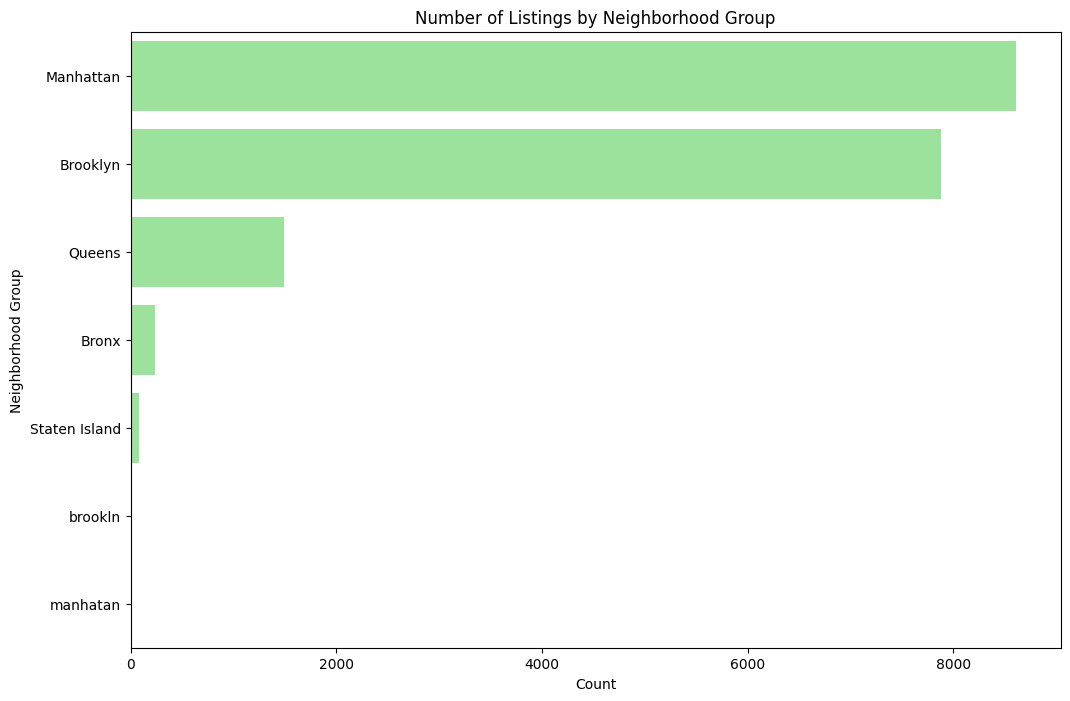

In [17]:
#Neighborhood Analysis
plt.figure(figsize=(12, 8))
sns.countplot(y='neighbourhood group', data=df,color="lightgreen" , order=df['neighbourhood group'].value_counts().index)
plt.title('Number of Listings by Neighborhood Group')
plt.xlabel('Count')
plt.ylabel('Neighborhood Group')
plt.show()

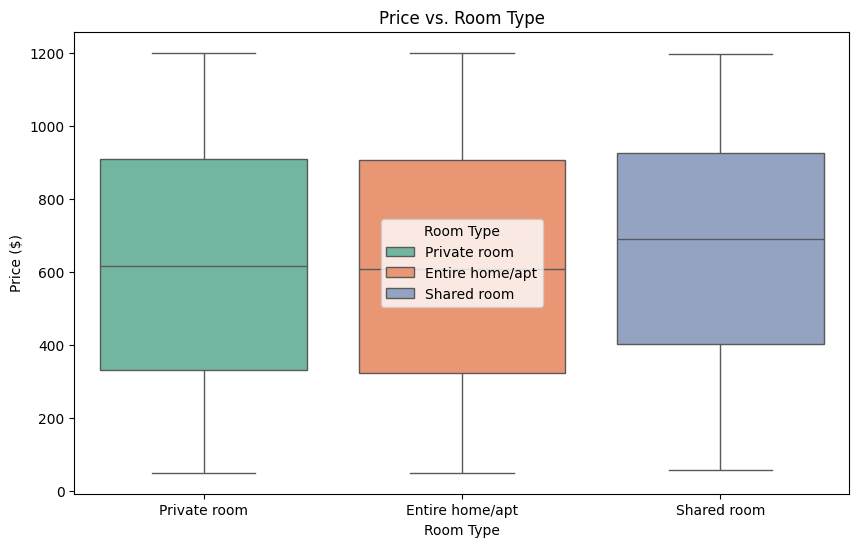

In [19]:
#Price vs. Room Type
plt.figure(figsize=(10, 6))
sns.boxplot(x='room type', y='price', hue='room type', data=df, palette='Set2')
plt.title('Price vs. Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.legend(title='Room Type')
plt.show()

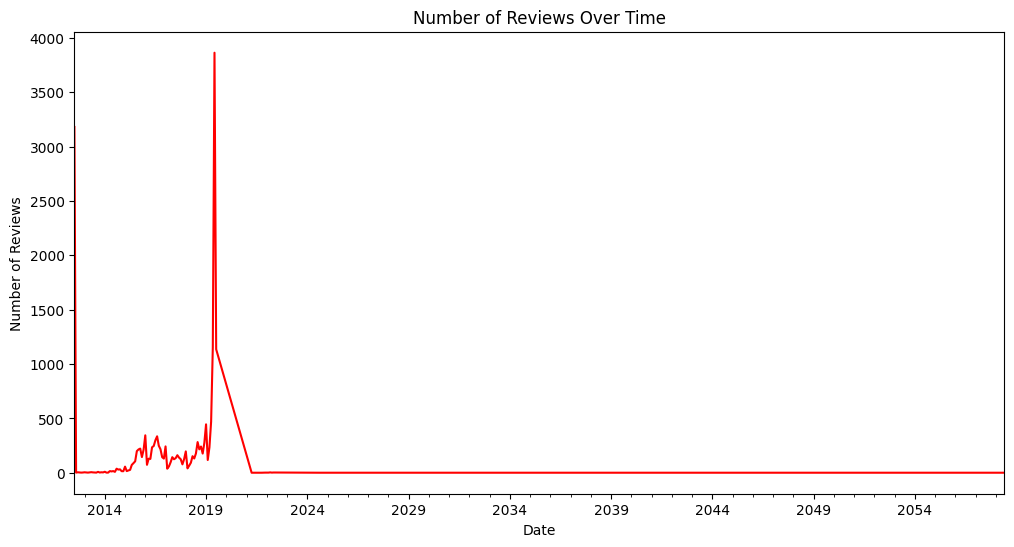

In [22]:
#Reviews Over Time
df['last review'] = pd.to_datetime(df['last review'])
reviews_over_time = df.groupby(df['last review'].dt.to_period('M')).size()

plt.figure(figsize=(12, 6))
reviews_over_time.plot(kind='line',color='red')
plt.title('Number of Reviews Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.show()

In [ ]:









-